# OOD and Perturbation Analysis

This notebook is reorganized around the new 7-model result set.

It covers four focused analyses:

- MBPP OOD performance
- overall TACO perturbation robustness
- lexical perturbation probe analysis
- a few example cases for qualitative inspection


In [1]:
%pip install pandas matplotlib seaborn jinja2


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re
import textwrap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path(".")


In [3]:
def clean_label(model_name):
    return (
        model_name
        .replace("cs4248-nlp/", "")
        .replace("-taco-hf-20260402-015143", "")
        .replace("-20260326-110507", "")
        .replace("paper-", "")
    )

def short_label(model_name):
    label = clean_label(model_name)
    if label.startswith("ft-teacher"):
        return "teacher"
    if label.startswith("s7-control"):
        return "control\nbs32"
    if label.startswith("s7-embed"):
        return "embed\ndw100 aw10"
    if label.startswith("s8-a2-bimga-uniform"):
        return "bimga\nuniform"
    if label.startswith("s8-hnp"):
        return "hnp\ndw100 pw10"
    if label.startswith("s9-bimga"):
        return "bimga\ndw50 aw10"
    if label.startswith("s9-score"):
        return "score\ndw100"
    label = re.sub(r"-tinybert-general-4l-312d", "", label)
    label = label.replace("-", " ")
    return textwrap.fill(label, width=16)

def method_family(model_name):
    label = clean_label(model_name)
    if label.startswith("ft-teacher"):
        return "teacher"
    if "control" in label:
        return "control"
    if "embed" in label:
        return "embed"
    if "score" in label:
        return "score"
    if "hnp" in label:
        return "hnp"
    if "bimga" in label:
        return "bimga"
    return "other"

def format_metric_table(df):
    return df.style.format({
        "mrr": "{:.3f}",
        "recall@1": "{:.3f}",
        "recall@5": "{:.3f}",
        "recall@10": "{:.3f}",
        "mean_rank": "{:.3f}",
        "median_rank": "{:.3f}",
        "runtime_sec": "{:.3f}",
        "delta_mrr_vs_clean": "{:.3f}",
        "delta_recall10_vs_clean": "{:.3f}",
        "avg_drop": "{:.3f}",
        "worst_drop": "{:.3f}",
        "match_rate": "{:.3f}",
        "avg_gold_rank": "{:.1f}",
    })


In [4]:
mbpp_metrics = pd.read_csv(DATA_DIR / "mbpp_ood__split-test__seed-42__models-7__tiers-clean__metrics.csv")
mbpp_per_query = pd.read_csv(DATA_DIR / "mbpp_ood__split-test__seed-42__models-7__tiers-clean__per_query_results.csv")
mbpp_examples = pd.read_csv(DATA_DIR / "mbpp_ood__split-test__seed-42__models-7__tiers-clean__example_cases.csv")
noisy_metrics = pd.read_csv(DATA_DIR / "taco_noisy__split-test__seed-42__models-7__tiers-clean-grammar_light-identifier_mask-keyword_neutralize-keyword_swap_type-keyword_synonym-mixed_heavy-mixed_light-structure_preserve_lexical_change-typo_heavy-typo_li.csv")

lexical_metric_paths = sorted(DATA_DIR.glob("taco_*__metrics.csv"))
lexical_probe_paths = sorted(DATA_DIR.glob("*lexical_probe_results.csv"))
example_case_paths = sorted(DATA_DIR.glob("taco_*__example_cases.csv"))

for frame in [mbpp_metrics, mbpp_per_query, mbpp_examples, noisy_metrics]:
    frame["label"] = frame["model_name"].map(short_label)
    frame["family"] = frame["model_name"].map(method_family)

model_order = mbpp_metrics.sort_values("mrr", ascending=False)["label"].tolist()

overview = pd.DataFrame(
    {
        "artifact": [
            "MBPP metrics",
            "MBPP per-query results",
            "MBPP example cases",
            "Noisy TACO metrics",
            "Lexical perturbation metric files",
            "Lexical probe files",
            "Perturbation example-case files",
        ],
        "rows": [
            len(mbpp_metrics),
            len(mbpp_per_query),
            len(mbpp_examples),
            len(noisy_metrics),
            len(lexical_metric_paths),
            len(lexical_probe_paths),
            len(example_case_paths),
        ],
    }
)

display(overview)
display(mbpp_metrics[["label", "mrr", "recall@1", "recall@5", "recall@10", "runtime_sec"]].sort_values("mrr", ascending=False))


,artifact,rows
0,MBPP metrics,7
1,MBPP per-query results,595
2,MBPP example cases,14
3,Noisy TACO metrics,77
4,Lexical perturbation metric files,3
5,Lexical probe files,5
6,Perturbation example-case files,2


,label,mrr,recall@1,recall@5,recall@10,runtime_sec
6,teacher,0.929893,0.894118,0.976471,0.976471,0.215507
4,bimga\ndw50 aw10,0.876094,0.823529,0.952941,0.976471,0.058849
2,bimga\nuniform,0.861383,0.800000,0.976471,0.976471,0.055593
1,embed\ndw100 aw10,0.840940,0.764706,0.929412,0.976471,0.056579
5,score\ndw100,0.833756,0.764706,0.905882,0.941176,0.079920
3,hnp\ndw100 pw10,0.796793,0.717647,0.894118,0.941176,0.054127
0,control\nbs32,0.702623,0.588235,0.835294,0.894118,0.155378


## MBPP OOD

This section focuses on the clean MBPP OOD run for the 7 selected models.
It includes a full metric table, a comparison plot, and the per-query reciprocal-rank distribution.

,label,family,mrr,recall@1,recall@5,recall@10,mean_rank,median_rank,runtime_sec,query_count,code_count
6,teacher,teacher,0.930,0.894,0.976,0.976,1.388,1.000,0.216,85,85
4,bimga dw50 aw10,bimga,0.876,0.824,0.953,0.976,2.118,1.000,0.059,85,85
2,bimga uniform,bimga,0.861,0.800,0.976,0.976,2.235,1.000,0.056,85,85
1,embed dw100 aw10,embed,0.841,0.765,0.929,0.976,2.106,1.000,0.057,85,85
5,score dw100,score,0.834,0.765,0.906,0.941,2.294,1.000,0.080,85,85
3,hnp dw100 pw10,hnp,0.797,0.718,0.894,0.941,2.671,1.000,0.054,85,85
0,control bs32,control,0.703,0.588,0.835,0.894,4.812,1.000,0.155,85,85


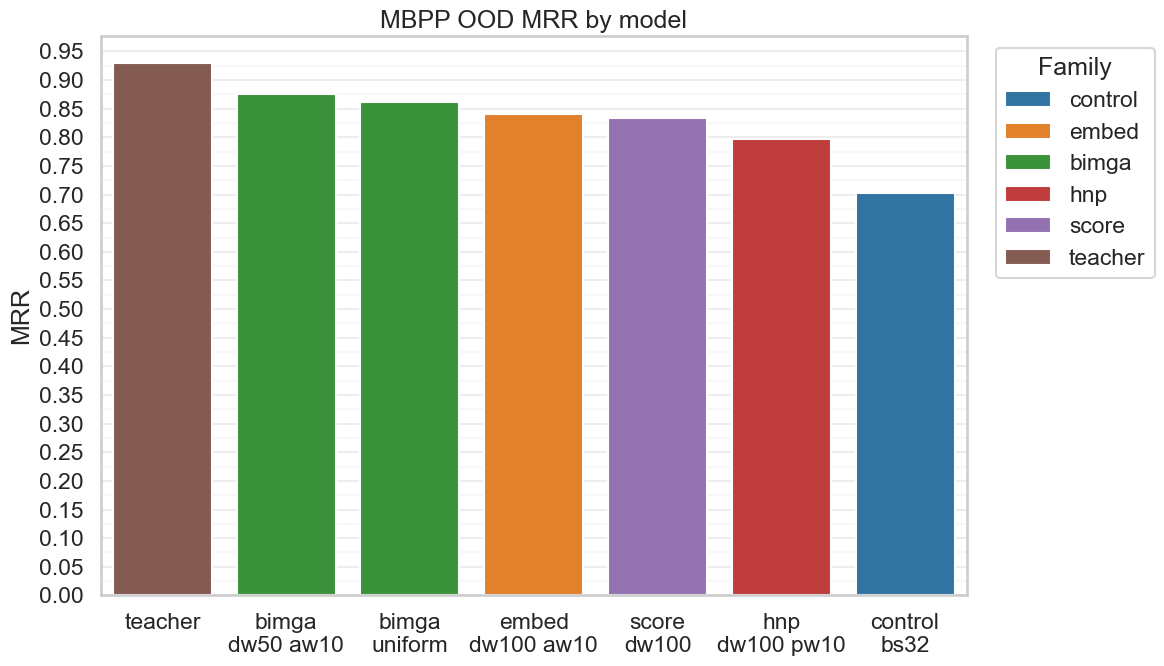

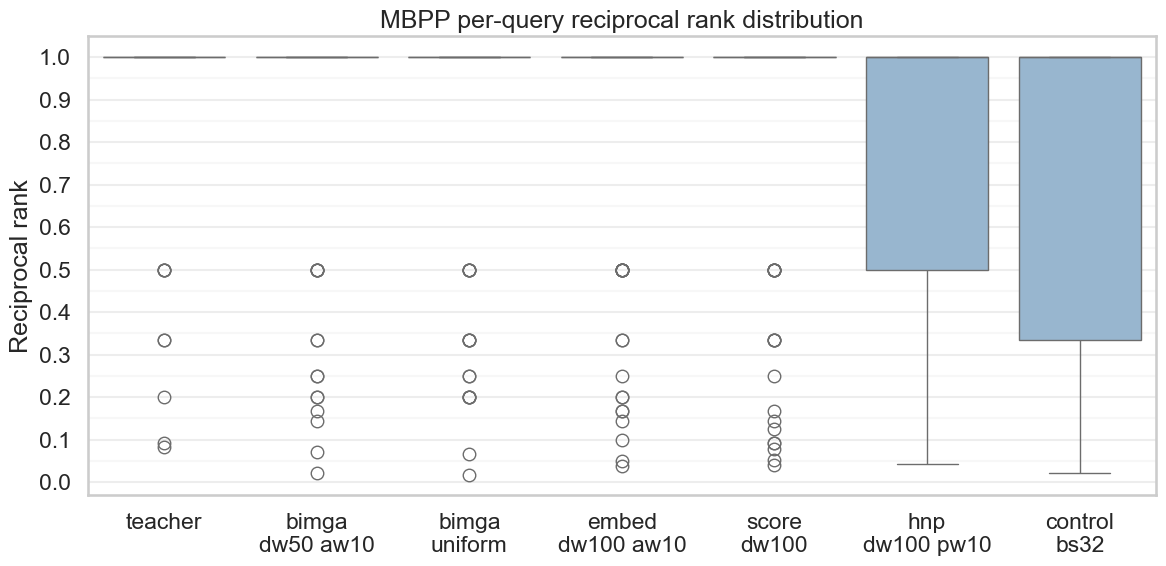

In [11]:
mbpp_display = mbpp_metrics[[
    "label",
    "family",
    "mrr",
    "recall@1",
    "recall@5",
    "recall@10",
    "mean_rank",
    "median_rank",
    "runtime_sec",
    "query_count",
    "code_count",
]].sort_values("mrr", ascending=False)
display(format_metric_table(mbpp_display))

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=mbpp_metrics, x="label", y="mrr", hue="family", order=model_order, dodge=False, palette="tab10")
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.yaxis.set_minor_locator(MultipleLocator(0.025))
ax.grid(True, axis="y", which="major", alpha=0.35)
ax.grid(True, axis="y", which="minor", alpha=0.15)
plt.title("MBPP OOD MRR by model")
plt.xlabel("")
plt.ylabel("MRR")
plt.legend(title="Family", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=mbpp_per_query, x="label", y="reciprocal_rank", order=model_order, color="#8fb7d8")
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.grid(True, axis="y", which="major", alpha=0.35)
ax.grid(True, axis="y", which="minor", alpha=0.15)
plt.title("MBPP per-query reciprocal rank distribution")
plt.xlabel("")
plt.ylabel("Reciprocal rank")
plt.tight_layout()
plt.show()


## Overall Perturbation Robustness

This section uses the 11-tier noisy TACO summary file.
The main views are a model-by-tier heatmap of MRR drop and a summary table of average / worst-case degradation.

,label,family,clean_mrr,avg_drop,worst_drop,avg_recall10_drop
3,embed dw100 aw10,embed,0.302592,-0.071,-0.163,-0.085400
2,control bs32,control,0.205197,-0.073,-0.144,-0.103500
5,score dw100,score,0.300787,-0.076,-0.181,-0.102900
0,bimga dw50 aw10,bimga,0.324940,-0.081,-0.192,-0.101800
4,hnp dw100 pw10,hnp,0.302256,-0.082,-0.179,-0.099400
1,bimga uniform,bimga,0.313260,-0.082,-0.187,-0.097100
6,teacher,teacher,0.429833,-0.092,-0.241,-0.106100


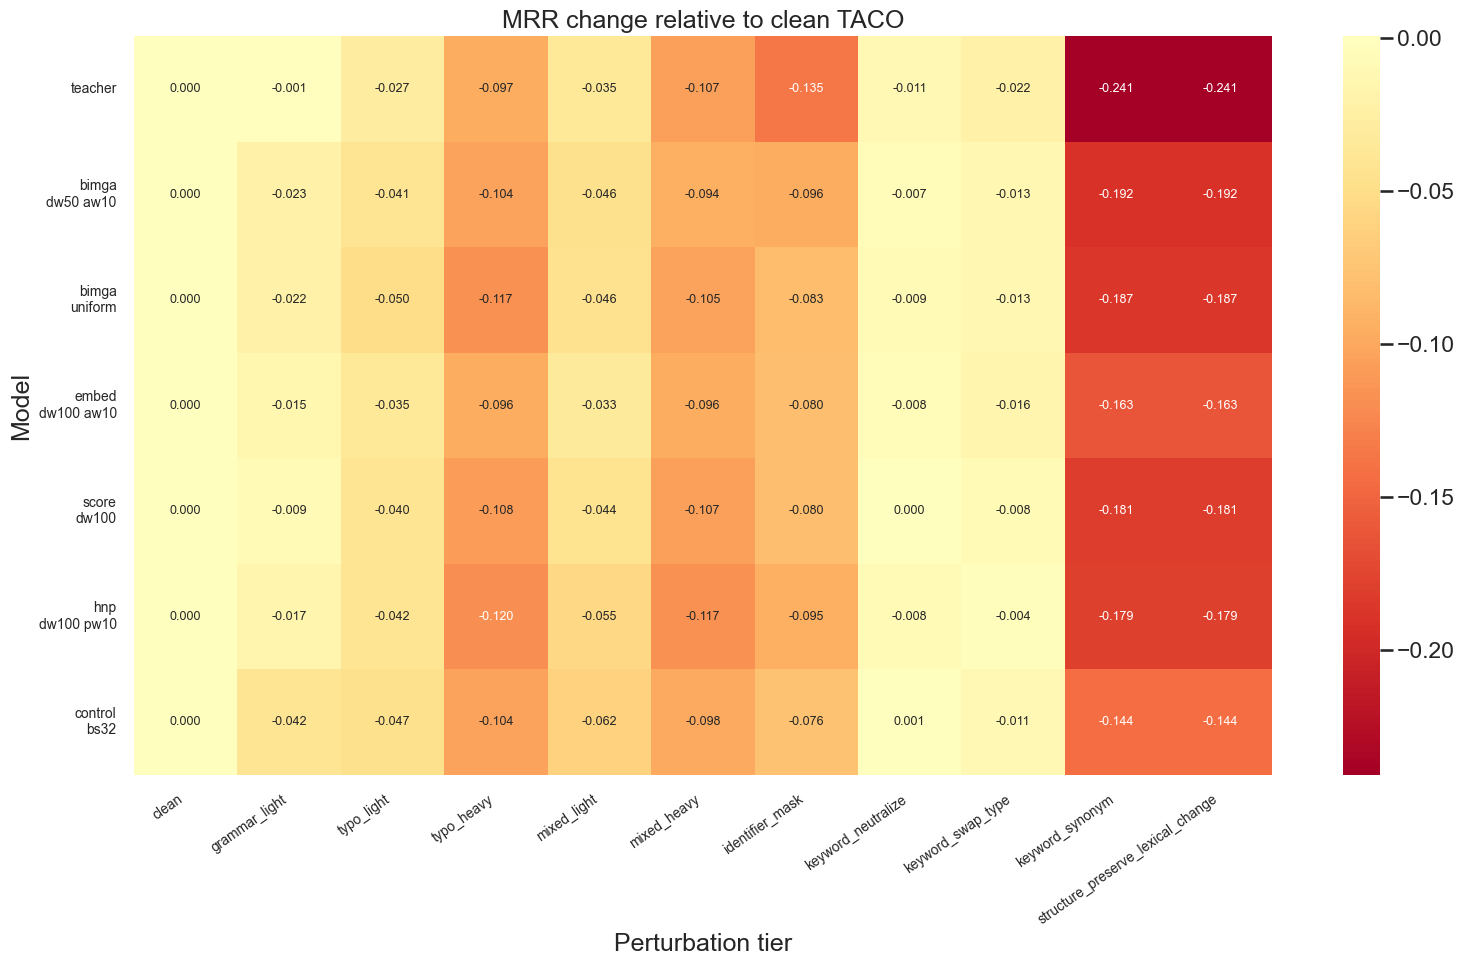

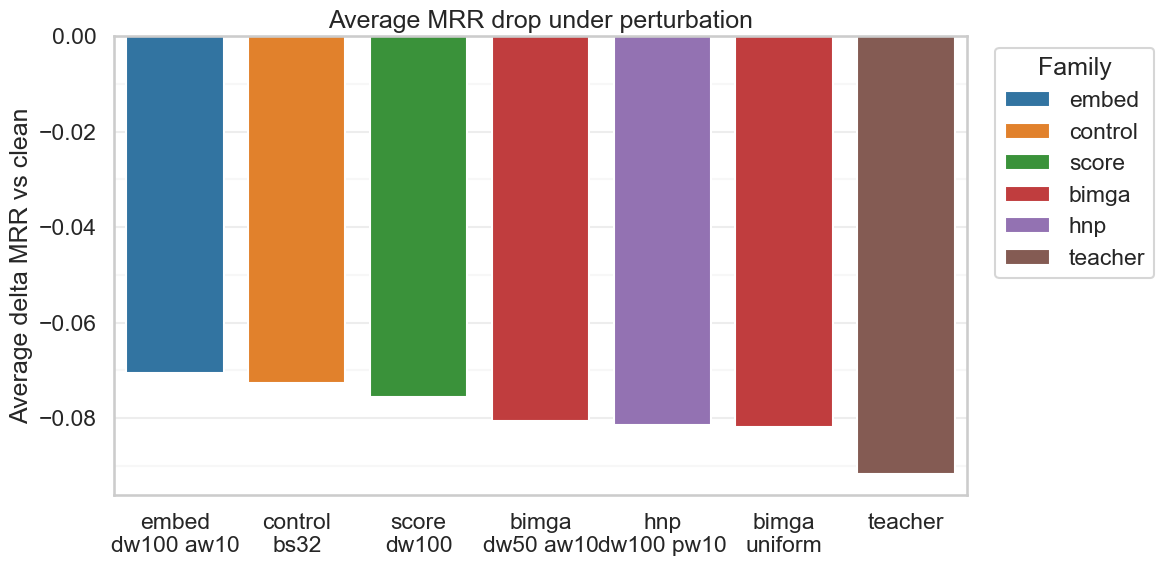

In [13]:
robust_summary = (
    noisy_metrics[noisy_metrics["perturbation_tier"] != "clean"]
    .groupby(["label", "family"], as_index=False)
    .agg(
        clean_mrr=("mrr", lambda s: float('nan')),
        avg_drop=("delta_mrr_vs_clean", "mean"),
        worst_drop=("delta_mrr_vs_clean", "min"),
        avg_recall10_drop=("delta_recall10_vs_clean", "mean"),
    )
)
clean_lookup = noisy_metrics[noisy_metrics["perturbation_tier"] == "clean"][['label', 'mrr']].rename(columns={'mrr': 'clean_mrr'})
robust_summary = robust_summary.drop(columns=['clean_mrr']).merge(clean_lookup, on='label', how='left')
robust_summary = robust_summary[['label', 'family', 'clean_mrr', 'avg_drop', 'worst_drop', 'avg_recall10_drop']].sort_values('avg_drop', ascending=False)
display(format_metric_table(robust_summary))

drop_heatmap = (
    noisy_metrics
    .pivot_table(index="label", columns="perturbation_tier", values="delta_mrr_vs_clean")
    .reindex(index=model_order)
    .reindex(columns=[
        "clean",
        "grammar_light",
        "typo_light",
        "typo_heavy",
        "mixed_light",
        "mixed_heavy",
        "identifier_mask",
        "keyword_neutralize",
        "keyword_swap_type",
        "keyword_synonym",
        "structure_preserve_lexical_change",
    ])
)

plt.figure(figsize=(16, 10))
sns.heatmap(drop_heatmap, annot=True, fmt='.3f', cmap='RdYlGn', center=0, annot_kws={'size': 9})
plt.title('MRR change relative to clean TACO')
plt.xlabel('Perturbation tier')
plt.ylabel('Model')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=robust_summary, x='label', y='avg_drop', hue='family', dodge=False, palette='tab10')
ax.yaxis.set_major_locator(MultipleLocator(0.02))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))
ax.grid(True, axis='y', which='major', alpha=0.35)
ax.grid(True, axis='y', which='minor', alpha=0.15)
plt.title('Average MRR drop under perturbation')
plt.xlabel('')
plt.ylabel('Average delta MRR vs clean')
plt.legend(title='Family', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Lexical Perturbation Probe Analysis

The lexical probe files are large, so this section aggregates them into compact model-by-perturbation summaries.
The two main outputs are lexical probe match rate and probe MRR.

,perturbation_tier,label,family,match_rate,avg_gold_rank,mrr
6,identifier_mask,teacher,teacher,0.217,98.0,0.294
1,identifier_mask,bimga uniform,bimga,0.155,106.1,0.230
0,identifier_mask,bimga dw50 aw10,bimga,0.155,106.3,0.229
3,identifier_mask,embed dw100 aw10,embed,0.152,112.5,0.223
5,identifier_mask,score dw100,score,0.149,110.3,0.221
4,identifier_mask,hnp dw100 pw10,hnp,0.135,120.3,0.207
2,identifier_mask,control bs32,control,0.076,174.7,0.129
13,keyword_neutralize,teacher,teacher,0.334,60.3,0.419
7,keyword_neutralize,bimga dw50 aw10,bimga,0.235,76.0,0.318
8,keyword_neutralize,bimga uniform,bimga,0.223,77.6,0.304


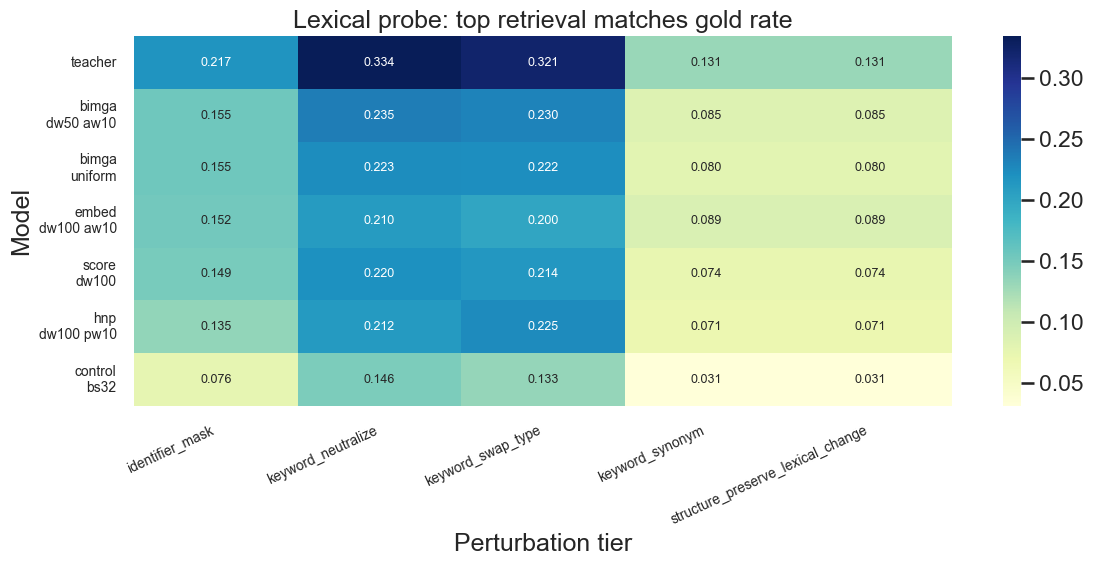

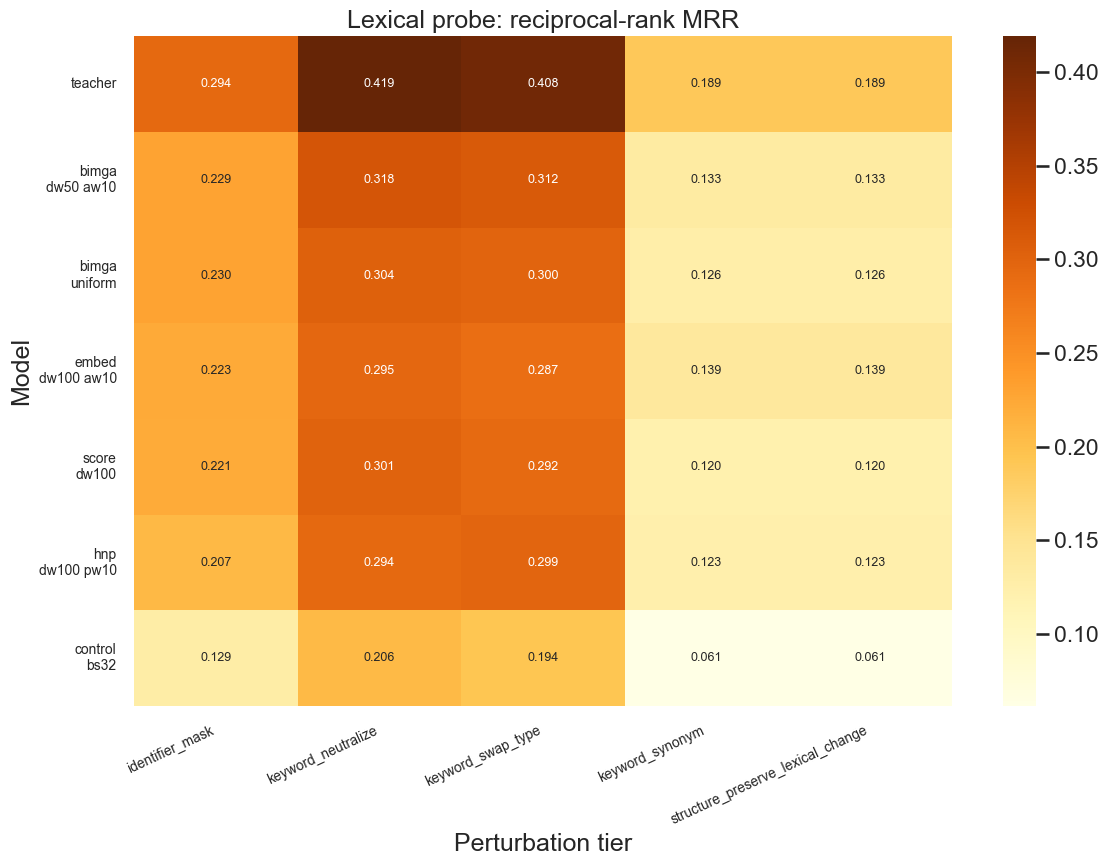

In [ ]:
probe_frames = []
for path in lexical_probe_paths:
    probe = pd.read_csv(path, usecols=[
        'model_name',
        'perturbation_tier',
        'gold_rank',
        'reciprocal_rank',
        'top_retrieved_matches_gold',
    ])
    probe['label'] = probe['model_name'].map(short_label)
    probe['family'] = probe['model_name'].map(method_family)
    probe_frames.append(probe)

lexical_probe = pd.concat(probe_frames, ignore_index=True)
lexical_summary = (
    lexical_probe.groupby(['perturbation_tier', 'label', 'family'], as_index=False)
    .agg(
        match_rate=('top_retrieved_matches_gold', 'mean'),
        avg_gold_rank=('gold_rank', 'mean'),
        mrr=('reciprocal_rank', 'mean'),
    )
)
display(format_metric_table(lexical_summary.sort_values(['perturbation_tier', 'mrr'], ascending=[True, False])))

match_heatmap = lexical_summary.pivot_table(index='label', columns='perturbation_tier', values='match_rate').reindex(index=model_order)
mrr_heatmap = lexical_summary.pivot_table(index='label', columns='perturbation_tier', values='mrr').reindex(index=model_order)

plt.figure(figsize=(12, 6))
sns.heatmap(match_heatmap, annot=True, fmt='.3f', cmap='YlGnBu', annot_kws={'size': 9})
plt.title('Lexical probe: top retrieval matches gold rate')
plt.xlabel('Perturbation tier')
plt.ylabel('Model')
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(mrr_heatmap, annot=True, fmt='.3f', cmap='YlOrBr', annot_kws={'size': 9})
plt.title('Lexical probe: reciprocal-rank MRR')
plt.xlabel('Perturbation tier')
plt.ylabel('Model')
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


## Example Cases

These are lightweight qualitative views for quick inspection, not full exhaustive analysis.

In [8]:
print('MBPP example cases')
display(mbpp_examples[[
    'case_type',
    'label',
    'record_id',
    'clean_rank',
    'perturbed_rank',
    'delta_rank',
    'top_retrieved_code_summary',
]].sort_values(['case_type', 'label']))

example_frames = []
for path in example_case_paths:
    ex = pd.read_csv(path)
    ex['label'] = ex['model_name'].map(short_label)
    example_frames.append(ex)

if example_frames:
    perturb_examples = pd.concat(example_frames, ignore_index=True)
    perturb_examples = perturb_examples.sort_values(['perturbation_tier', 'case_type', 'delta_rank'], ascending=[True, True, False])
    display(perturb_examples[[
        'perturbation_tier',
        'case_type',
        'label',
        'record_id',
        'clean_rank',
        'perturbed_rank',
        'delta_rank',
        'top_retrieved_code_summary',
    ]].head(20))


MBPP example cases


,case_type,label,record_id,clean_rank,perturbed_rank,delta_rank,top_retrieved_code_summary
11,mbpp_ood_failure,bimga\ndw50 aw10,603,49,49,0,def get_ludic(n):
7,mbpp_ood_failure,bimga\nuniform,603,57,57,0,def get_ludic(n):
3,mbpp_ood_failure,control\nbs32,603,47,47,0,def get_ludic(n):
5,mbpp_ood_failure,embed\ndw100 aw10,603,27,27,0,def get_ludic(n):
9,mbpp_ood_failure,hnp\ndw100 pw10,603,24,24,0,def get_ludic(n):
13,mbpp_ood_failure,score\ndw100,623,25,25,0,"def nth_nums(nums,n):"
1,mbpp_ood_failure,teacher,572,12,12,0,def two_unique_nums(nums):
10,mbpp_ood_success,bimga\ndw50 aw10,262,1,1,0,"def split_two_parts(list1, L):"
6,mbpp_ood_success,bimga\nuniform,262,1,1,0,"def split_two_parts(list1, L):"
2,mbpp_ood_success,control\nbs32,227,1,1,0,"def min_of_three(a,b,c):"


,perturbation_tier,case_type,label,record_id,clean_rank,perturbed_rank,delta_rank,top_retrieved_code_summary
0,keyword_neutralize,keyword_failure,control\nbs32,test:760,207,525,318,from functools import reduce
12,keyword_neutralize,keyword_failure,teacher,test:135,6,295,289,import math
8,keyword_neutralize,keyword_failure,bimga\ndw50 aw10,test:135,15,303,288,from heapq import *
2,keyword_neutralize,keyword_failure,embed\ndw100 aw10,test:515,218,426,208,"from sys import stdin, stdout"
4,keyword_neutralize,keyword_failure,bimga\nuniform,test:186,54,244,190,"def check(n, m):"
6,keyword_neutralize,keyword_failure,hnp\ndw100 pw10,test:48,81,257,176,x = int(input())
10,keyword_neutralize,keyword_failure,score\ndw100,test:186,52,204,152,"import sys, os, io"
11,keyword_neutralize,keyword_success,score\ndw100,test:551,296,212,-84,def main():
5,keyword_neutralize,keyword_success,bimga\nuniform,test:583,193,87,-106,import os
7,keyword_neutralize,keyword_success,hnp\ndw100 pw10,test:524,717,607,-110,def beat(arr):


## Discussion and Interpretation

### 1. MBPP OOD performance

The MBPP OOD results show a clear separation between the non-distilled baseline, the KD variants, and the teacher. The teacher remains the strongest overall model with `MRR = 0.930`, `R@1 = 0.894`, and `mean_rank = 1.39`, which is expected because it has the highest capacity and is the direct source of the distilled signal. However, the gap between the best students and the teacher is not especially large. The strongest student in this run is `bimga dw50 aw10` with `MRR = 0.876`, followed by `bimga uniform` at `0.861` and `embed dw100 aw10` at `0.841`. In contrast, the control baseline is much weaker at `MRR = 0.703` and `mean_rank = 4.81`.

The most important takeaway is that every KD method in this selected set substantially outperforms the control model on MBPP OOD. Relative to control, the gains are large in absolute terms: roughly `+0.17` MRR for `bimga dw50 aw10`, `+0.16` for `bimga uniform`, `+0.14` for `embed`, `+0.13` for `score`, and `+0.09` for `hnp`. That pattern strongly suggests that the benefit of KD is not method-specific noise; rather, distillation itself appears to improve out-of-distribution retrieval, while the exact KD formulation determines how much of that improvement is realized.

A plausible explanation is that KD helps the student inherit a smoother and more semantically organized retrieval space from the teacher. MBPP OOD retrieval is not just about memorizing specific lexical templates; it requires recognizing function intent under wording and topic shifts. A control student trained only on the standard objective likely learns a weaker decision boundary and relies more on shallow lexical overlap, which hurts generalization. In contrast, KD provides richer supervision: the student does not merely learn the correct answer, but also learns which near-misses should rank higher or lower. That richer ranking signal likely explains why all distillation variants beat the control.

The fact that the two BIMGA variants are strongest is also suggestive. Even without the exact formal definition of BIMGA in this notebook, the empirical pattern implies that it transfers information that is especially useful for retrieval generalization. One possibility is that BIMGA preserves either pairwise structure or representation geometry more effectively than the other KD objectives, allowing the student to keep semantically relevant candidates near the query even when the query differs from the training distribution. `embed` is also strong, which is consistent with the idea that feature-level alignment is particularly helpful for OOD retrieval. `score` and `hnp` still help, but they seem to transfer less of the teacher's generalization ability.

### 2. Overall perturbation robustness

The perturbation analysis tells a more nuanced story than MBPP. On clean TACO retrieval, the teacher again has the highest absolute performance (`clean_mrr = 0.430`), and the best students cluster between roughly `0.30` and `0.325`, while the control is much lower at `0.205`. So KD clearly improves the starting point before any perturbation is applied. However, once perturbations are introduced, the teacher is not the most stable model in relative terms. Its average drop is `-0.092`, which is worse than every student in the selected set.

Among the students, `embed dw100 aw10` has the smallest average MRR drop (`-0.071`), narrowly ahead of the control (`-0.073`) and noticeably ahead of both BIMGA variants and `hnp` (all around `-0.081`). `score` sits in the middle at `-0.076`. This means that the best model for clean performance is not necessarily the best model for perturbation stability. `bimga dw50 aw10` has the best clean student MRR, but `embed` is the most robust on average.

That tradeoff is meaningful. One interpretation is that some KD methods optimize more aggressively for peak ranking quality, while others produce a representation space that is more resistant to lexical corruption. `embed` likely encourages the student to mimic the teacher's internal feature geometry rather than just its final ranking preferences. If that is true, then mild to moderate perturbations may move the query embedding less drastically, which would explain why `embed` degrades more gracefully. In contrast, a method that pushes harder for ranking sharpness may achieve better clean performance but become more sensitive when key lexical cues are disrupted.

It is also notable that the control model is not the worst by average drop, even though it is much weaker in absolute clean performance. This is a good reminder that absolute drop and clean score measure different things. A weaker model can appear more stable simply because it starts from a lower baseline and has less ranking quality to lose. For that reason, the most meaningful comparison is not average drop alone, but the combination of clean performance and degradation. From that perspective, `embed` is particularly attractive because it keeps a strong clean score while also showing the best average robustness among the students.

### 3. Which perturbations are most damaging?

The most damaging perturbations are the semantic or lexical rewrites rather than the lighter surface-level changes. For four models (`bimga dw50 aw10`, `bimga uniform`, `score`, and `embed`), the worst tier is `keyword_synonym`. For the teacher, and also for `hnp` and the control, the worst tier is `structure_preserve_lexical_change`. These worst-case drops are much larger than the average losses: for example, the teacher falls by `-0.241` MRR on `structure_preserve_lexical_change`, and `bimga dw50 aw10` falls by `-0.192` on `keyword_synonym`.

This pattern suggests that the retrieval systems depend strongly on lexical anchors that remain semantically informative in the original queries. When those anchors are replaced with synonyms, neutralized, or rewritten while preserving structure, the models often lose access to the most discriminative cues. In other words, they appear more robust to small form noise than to meaning-preserving lexical substitution. This is a common failure mode in retrieval systems: the underlying intent is preserved, but the surface realization changes enough that embedding alignment or token overlap no longer behaves as expected.

At the same time, not all lexical perturbations are equally destructive. In the probe results, `keyword_neutralize` and `keyword_swap_type` remain much easier than `keyword_synonym` and `structure_preserve_lexical_change`. Averaged across models, the lexical probe `match_rate` is about `0.226` for `keyword_neutralize` and `0.221` for `keyword_swap_type`, but only about `0.080` for both `keyword_synonym` and `structure_preserve_lexical_change`. This large gap supports the hypothesis that synonym replacement and structural lexical rewriting alter the query representation more fundamentally than the more local keyword operations.

### 4. Lexical probe analysis

The lexical probe results are especially useful because they expose a sharper version of the same ranking pattern. Averaged across perturbation-specific probe files, the teacher achieves the best lexical probe performance (`avg_probe_mrr ≈ 0.300`, `avg_match_rate ≈ 0.227`), and the control model is far behind (`avg_probe_mrr ≈ 0.130`, `avg_match_rate ≈ 0.083`). All KD students fall between these extremes, with `bimga dw50 aw10` leading the student group, followed closely by `bimga uniform` and `embed`.

This strengthens the interpretation from the MBPP results: KD appears to improve not only end-task retrieval quality, but also the underlying lexical-semantic matching behavior of the student. The control model's much worse average gold rank (`~198.6` versus `~126` to `~133` for the KD students) suggests that it frequently loses the gold candidate by a large margin once the lexical surface is altered. Distillation seems to compress some of the teacher's robustness into the student, making the student less brittle when the query no longer matches the expected wording exactly.

The two BIMGA variants again look strong on the lexical probes, which may indicate that they preserve the teacher's retrieval neighborhood structure more effectively than the other KD objectives. `embed` remains competitive and is arguably the most balanced method across the notebook: it is not always the single best method on clean MBPP, but it is consistently near the top on OOD, robustness, and lexical probing. That consistency makes it a compelling choice when robustness is more important than squeezing out the absolute best clean metric.

### 5. Overall interpretation

Taken together, the results support three high-level conclusions.

First, KD clearly improves OOD retrieval relative to the control student. This is strongest on MBPP, where every KD variant meaningfully outperforms the baseline. Second, KD also improves perturbation robustness in absolute performance terms, because all KD students start from much stronger clean TACO retrieval than the control. Third, there is a real tradeoff between clean effectiveness and perturbation stability: methods like BIMGA appear strongest for peak OOD performance, while `embed` appears strongest for average robustness under lexical corruption.

The most plausible explanation is that KD helps the student internalize a richer semantic similarity structure from the teacher. Smaller students are likely too limited to learn that structure as effectively from the base objective alone, so the teacher provides a useful inductive bias. Different KD methods then emphasize different aspects of the teacher signal. Methods that align internal representations may yield better perturbation stability, while methods that sharpen ranking behavior may maximize clean-task performance. This framework is consistent with the empirical pattern in the new data: `bimga` is the strongest clean OOD student, `embed` is the most stable student under perturbation, and the control model remains clearly behind on both fronts.

### 6. Practical takeaway for the report

KD is clearly beneficial for both OOD generalization and perturbation robustness, but the best KD method depends on the evaluation target. BIMGA gives the strongest clean OOD retrieval, while embedding-based KD gives the most reliable robustness under perturbation.